# 位置情報は緯度経度で距離感を加味したいな！
# validationデータの切り方も重要か？

★実行環境の選択

In [1]:
# VSCodeの場合
edi_flg = 1
# Googlre Colabの場合
# edi_flg = 0

In [2]:
if edi_flg == 0:
  # GoogleColabにGitHubリポジトリをクローンする用
  %cd /content/My_Python_project

  from google.colab import auth
  auth.authenticate_user()
  !git clone https://github.com/keiseki-eng/My_Python_project
  !git pull origin main



In [3]:
# import sys
# !{sys.executable} -m pip install ipykernel

In [4]:
import os
import sys
import yaml
import pandas as pd
import numpy as np
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt
import japanize_matplotlib

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, KFold

# srcディレクトリをPythonの検索パスに追加
sys.path.append("/home/keiseki/JR_train_snow/30.src")

# validation.pyからsplit_timeを読み込み
from utils.validation import split_time

/home/keiseki/JR_train_snow/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
if edi_flg == 0:
  from google.colab import drive
  drive.mount('/content/drive')

In [6]:
import warnings
warnings.filterwarnings(
    "ignore",
    category=pd.errors.PerformanceWarning
)

## 01.config読み込み

In [7]:
# VSCode用
if edi_flg==1:
  conf_path = os.path.join( '../00.config/config.yaml')
  path_set = os.path.join('../00.config/path.yaml')
  with open(conf_path, 'r') as f:
    config = yaml.safe_load(f)
  with open(path_set, 'r') as f:
    path_config = yaml.safe_load(f)

# GoogleColab用
elif edi_flg==0:
  conf_path = "My_Python_project/config/config.yaml"
  path_set = "My_Python_project/config/path.yaml"
  with open(conf_path, "r") as f:
    config = yaml.safe_load(f)
  with open(path_set, "r") as f:
    path_config = yaml.safe_load(f)

In [8]:
# 定義した特徴量リストを読み込み
feature_list = config['FEATURE']['FEATURE_LIST']
# カテゴリカルカラムのリストを定義
categorical_cols = config['FEATURE']['CATEGORICAL_COLS']

# 気象データ分
locations = config["WEATHER_FEATURE"]["locations"]
variables = config["WEATHER_FEATURE"]["variables"]
hours = config["WEATHER_FEATURE"]["hours"]
w_categories = config["WEATHER_CATEGORY"]["WEATHER_CATEGORY_LIST"]

# 気象データの特徴量リストを作成
weather_feature_cols = [
    f"{location}_{variable}_{hour}"
    for location in locations
    for variable in variables
    for hour in hours
]
weather_categorical_cols = [
    f"{location}_{w_category}_{hour}"
    for location in locations
    for w_category in w_categories
    for hour in hours
]

# 積雪計データ分
snow_locations = config["SNOW_FEATURE"]["locations"]
snow_variables = config["SNOW_FEATURE"]["variables"]
snow_statistics = config["SNOW_FEATURE"]["statistics"]
snow_time_zones = config["SNOW_FEATURE"]["time_zones"]
snow_categories = config["SNOW_CATEGORY"]["SNOW_CATEGORY_LIST"]

# 積雪計データの特徴量リストを作成
snow_feature_cols = [
    f"{location}_{variable}_{statistic}_{time_zone}"
    for location in snow_locations
    for variable in snow_variables
    for statistic in snow_statistics
    for time_zone in snow_time_zones
]
snow_categorical_cols = [
    f"{location}_{snow_category}_{time_zone}"
    for location in snow_locations
    for snow_category in snow_categories
    for time_zone in snow_time_zones
]

# 通常の特徴量リストに気象データ分を追加
feature_list += weather_feature_cols
categorical_cols += weather_categorical_cols
# 通常の特徴量リストに積雪計データ分を追加
feature_list += snow_feature_cols
categorical_cols += snow_categorical_cols

# validationの分割日を設定
split_date = config["split_date"]

In [ ]:
# 学習データ、テストデータの読み込み
train_data_path = path_config['INTERIUM_PATH']['train_data']
test_data_path = path_config['INTERIUM_PATH']['test_data']

df_train = pd.read_pickle(train_data_path)
df_test = pd.read_pickle(test_data_path)


KeyboardInterrupt: 

## addr1+2に対し、ターゲットエンコーディングを実装

In [ ]:
# df_train, addr1_2_global_mean = target_encode_oof(
#     df_train,
#     col="addr1+2",
#     target="money_room",
#     n_splits=5,
#     smoothing=20
# )


## interaction特徴量を追加

## 05.train/valid 分割　＆　target加工

In [ ]:
# feature_listに存在しないカラムがあれば、NaNで追加
fix_list = feature_list + ["年月日", "合計"]
df_train = df_train.reindex(columns=fix_list)
# 時系列分析のため、train_test_splitではなくsplit_timeを使用
X_train, X_valid, y_train, y_valid, = split_time(df_train, split_col="年月日", target_col="合計", split_date=split_date)
# ランダム分割の場合
# X_train, X_valid, y_train, y_valid, = train_test_split(df_train, df_train["合計"], test_size=0.2, random_state=42)


train: 2016-01-19 00:00:00 ～ 2016-12-09 00:00:00
valid: 2016-12-10 00:00:00 ～ 2016-12-31 00:00:00
train件数: 4952
valid件数: 971


In [ ]:
print("train:")
print(X_train["年月日"].min(), "～", X_train["年月日"].max())

print("valid:")
print(X_valid["年月日"].min(), "～", X_valid["年月日"].max())

train:
2016-01-19 00:00:00 ～ 2016-12-09 00:00:00
valid:
2016-12-10 00:00:00 ～ 2016-12-31 00:00:00


## 07.モデル学習

In [ ]:
def wmae_eval(preds, train_data):
    y_true = train_data.get_label()

    # コンペ指定の重み
    weights = np.abs(y_true) * 1e4 + 1

    wmae = np.sum(weights * np.abs(y_true - preds)) / np.sum(weights)

    return "WMAE", wmae, False

In [ ]:
# 学習データの前処理:特徴量リストに限定
X_train = X_train[feature_list].copy()
X_valid = X_valid[feature_list].copy()
    
# ：object型の列をcategoryへ
cat_cols = [c for c in categorical_cols if c in X_train.columns]
# 明示的にobject型の全列もcategoryに変換（未指定のカテゴリ列がある場合に備えて）
obj_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

for df in [X_train, X_valid, df_test]:
    cols = sorted(set(cat_cols + obj_cols).intersection(df.columns))
    if cols:
        df[cols] = df[cols].astype("category")

/tmp/ipykernel_1544/4221972066.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_cols = X_train.select_dtypes(include=["object"]).columns.tolist()


In [ ]:
for col in [c for c in X_train.columns if "日照時間" in c]:
    X_train[col] = pd.to_numeric(X_train[col], errors="coerce")
    X_valid[col] = pd.to_numeric(X_valid[col], errors="coerce")


In [ ]:
# LightGBM のパラメータ設定
params = config['MODEL_PARAMS']

# LightGBM のデータセットを作成
lgb_train = lgb.Dataset(
    X_train,
    y_train,
    categorical_feature=categorical_cols
)


lgb_test = lgb.Dataset(
    X_valid,
    y_valid,
    reference=lgb_train,
    categorical_feature=categorical_cols
)


# モデルの学習
model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_test],
    feval=wmae_eval,
    callbacks=[
        lgb.early_stopping(100)
    ]
)

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[74]	training's WMAE: 0.00671335	valid_1's WMAE: 0.000450913


## 08.評価

特徴量の重要度


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

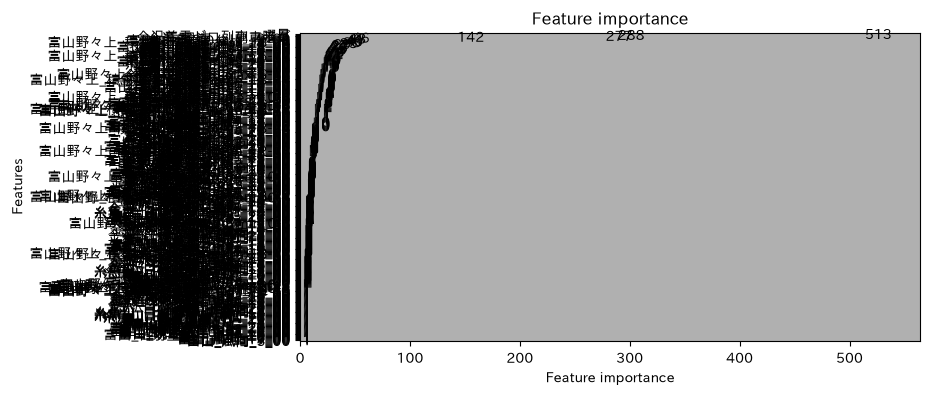

In [ ]:
# 検証データで予測
y_pred = model.predict(X_valid , num_iteration=model.best_iteration)


# 特徴量の重要度
print("特徴量の重要度")
lgb.plot_importance(model, figsize=(8,4))


## 09.可視化（importance SHAP）

In [ ]:

# import lightgbm as lgb
# from sklearn.model_selection import GridSearchCV

# # パラメータの探索範囲を指定
# param_grid = {
#     'num_leaves': [20, 30, 40],
#     'learning_rate': [0.01, 0.1, 0.5],
#     'max_depth': [5, 10]
# }




# # グリッドサーチCV
# gsearch = GridSearchCV(gbm, param_grid, cv=5) #cvは交差検証の回数

# # データを学習
# gsearch.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)])



# # 最適なパラメータとスコアを表示
# print('Best parameters found by grid search are:', gsearch.best_params_)
# print('Best score:', gsearch.best_score_)


In [ ]:
# # パラメータの辞書を結合
# best_params = {**params, **gsearch.best_params_}

# # 最適パラメータでモデルを再学習
# model = lgb.LGBMClassifier(**best_params)
# model.fit(X_train, y_train)

In [ ]:
#SHAP値の取得
explainer = shap.TreeExplainer(model=model)#SHAP値を取得するためのモデル作成
shap_values = explainer.shap_values(X=X_valid)#説明変数それぞれの値のSHAP値を取得する

# print(shap_values)
# print(shap_values.shape)


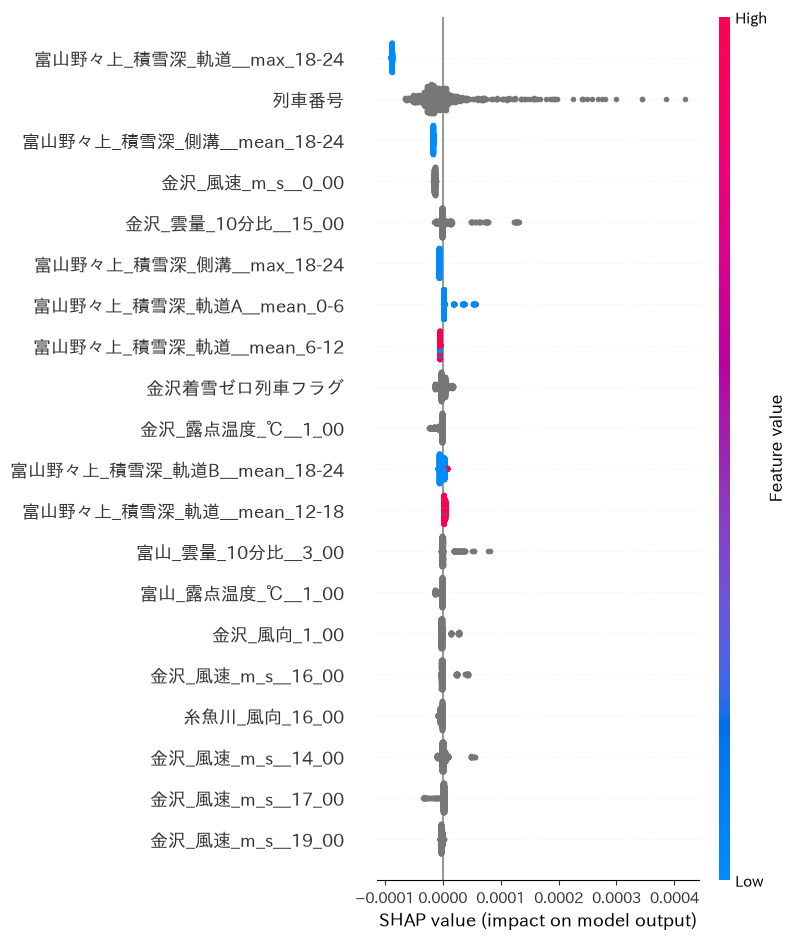

In [ ]:

# 変数別の影響度の可視化
shap.initjs()
# shap.summary_plot(shap_values, X_valid, plot_type="bar", show=False)
shap.summary_plot(shap_values, X_valid, show=False)


# 0番目のデータポイントを再選択
i = 0
single_observation = X_valid.iloc[i:i+1,:]


#print(single_observation)


# Explainerを使って説明を再計算
# single_shap_values = explainer(single_observation)

# waterfallプロットの生成
# shap.waterfall_plot(single_shap_values[0])

## 10.推論、提出

## 提出用データの作成

In [ ]:
# 特徴量の選定
# feature_listに存在しないカラムがあれば、NaNで追加
df_test_p = df_test.reindex(columns=feature_list)

for col in [c for c in X_train.columns if "日照時間" in c]:
    df_test_p[col] = pd.to_numeric(df_test_p[col], errors="coerce")


# 予測
y_pred  = model.predict(df_test_p)
# y_scores_submit = np.clip(y_pred, 6e6, 1e8)

print(y_pred)

[ 3.82342732e-04  4.36666051e-07  2.76708532e-04 ... -1.83525169e-06
 -3.88521479e-06 -2.84548909e-06]


In [ ]:

#提出用csvの作成
df_scores_submit = pd.DataFrame(y_pred)

# df_submit = pd.concat([df_test["id"], df_scores_submit], axis=1)
# df_scores_submit.index = df_scores_submit.index + 1
df_scores_submit.to_csv("submit.csv", index=True, header=False)




## 誤差要因分析

In [ ]:
import numpy as np
import pandas as pd

# Validデータを予測
y_pred = model.predict(X_valid)

# 誤差分析用DataFrame
error_df = X_valid.copy()

error_df["実測値"] = y_valid.values
error_df["予測値"] = y_pred

# 符号付き誤差
# プラス：実測 > 予測 → 過小予測
# マイナス：実測 < 予測 → 過大予測
error_df["誤差"] = error_df["実測値"] - error_df["予測値"]

# 絶対誤差
error_df["絶対誤差"] = np.abs(error_df["誤差"])

# コンテスト評価と同じ重み
error_df["重み"] = np.abs(error_df["実測値"]) * 1e4 + 1

# WMAE用の加重絶対誤差
error_df["加重絶対誤差"] = (
    error_df["重み"] * error_df["絶対誤差"]
)

print(f"Valid件数: {len(error_df):,}")
print(f"Valid MAE : {error_df['絶対誤差'].mean():.6f}")
print(
    f"Valid WMAE: "
    f"{error_df['加重絶対誤差'].sum() / error_df['重み'].sum():.9f}"
)

print(
    error_df[
        ["実測値", "予測値", "誤差", "絶対誤差"]
    ]
    .describe()
)
# 誤差が大きい順に確認
error_df.sort_values(
    "絶対誤差",
    ascending=False
)[
    ["実測値", "予測値", "誤差", "絶対誤差"]
].head(20)

Valid件数: 971
Valid MAE : 0.000054
Valid WMAE: 0.000450913
              実測値           予測値            誤差          絶対誤差
count  971.000000  9.710000e+02  9.710000e+02  9.710000e+02
mean     0.000027  1.905059e-05  7.852177e-06  5.441755e-05
std      0.000235  7.300300e-05  2.313141e-04  2.249525e-04
min      0.000000 -5.224990e-05 -7.293637e-04  1.652669e-08
25%      0.000000 -7.764413e-06 -1.522355e-05  4.146282e-06
50%      0.000000 -2.665392e-07  5.075643e-07  1.118331e-05
75%      0.000000  1.569953e-05  8.039790e-06  2.989574e-05
max      0.003791  7.293637e-04  3.595452e-03  3.595452e-03


,実測値,予測値,誤差,絶対誤差
14610,0.003791,1.954746e-04,0.003595,0.003595
14613,0.002692,9.642966e-05,0.002595,0.002595
14632,0.002555,-1.133292e-05,0.002566,0.002566
14646,0.002940,4.195820e-04,0.002521,0.002521
14615,0.002224,5.541655e-04,0.001670,0.001670
14647,0.001534,4.325122e-06,0.001530,0.001530
14628,0.001350,2.575800e-08,0.001350,0.001350
14621,0.001195,1.973250e-06,0.001193,0.001193
14630,0.001255,1.727675e-04,0.001082,0.001082
14622,0.000982,1.266408e-05,0.000970,0.000970


In [ ]:
error_df["実測値_bin"] = pd.cut(
    error_df["実測値"],
    bins=[-np.inf, 0, 0.01, 0.03, 0.05, 0.1, 0.2, np.inf]
)

summary = error_df.groupby(
    "実測値_bin",
    observed=True
).agg(
    件数=("実測値", "size"),
    平均実測=("実測値", "mean"),
    平均予測=("予測値", "mean"),
    MAE=("絶対誤差", "mean"),
    WMAE=("加重絶対誤差", "sum")
)

summary["WMAE"] = (
    summary["WMAE"]
    / error_df.groupby("実測値_bin", observed=True)["重み"].sum()
)

print(summary)

              件数      平均実測      平均予測       MAE      WMAE
実測値_bin                                                 
(-inf, 0.0]  953  0.000000  0.000018  0.000030  0.000030
(0.0, 0.01]   18  0.001451  0.000095  0.001356  0.001888


In [ ]:
train_summary = error_df.groupby("列車番号").agg(
    件数=("実測値", "size"),
    平均実測=("実測値", "mean"),
    平均予測=("予測値", "mean"),
    MAE=("絶対誤差", "mean"),
    加重誤差=("加重絶対誤差", "sum"),
    重み=("重み", "sum")
)

train_summary["WMAE"] = (
    train_summary["加重誤差"]
    / train_summary["重み"]
)

print(
    train_summary
    .sort_values("WMAE", ascending=False)
    .head(30)
)

       件数      平均実測          平均予測       MAE      加重誤差        重み      WMAE
列車番号                                                                     
9536E  23  0.000165  5.565425e-05  0.000218  0.141307  60.90927  0.002320
3502E  23  0.000128  1.736103e-04  0.000265  0.080215  52.40367  0.001531
554E   44  0.000061  2.943786e-05  0.000095  0.074049  70.91817  0.001044
574E   44  0.000058 -1.272389e-07  0.000071  0.068702  69.54972  0.000988
3500E  23  0.000097  2.528195e-04  0.000301  0.044071  45.24091  0.000974
562E   44  0.000035  1.497870e-06  0.000047  0.025543  59.33896  0.000430
578E   44  0.000031  1.904661e-06  0.000044  0.020153  57.49566  0.000351
558E   44  0.000029  2.993946e-05  0.000078  0.017027  56.54784  0.000301
566E   44  0.000027  6.800132e-07  0.000040  0.016009  55.94695  0.000286
590E   44  0.000022  4.648196e-06  0.000038  0.011203  53.82470  0.000208
570E   44  0.000022 -2.235985e-06  0.000034  0.010701  53.54105  0.000200
568E   44  0.000021  3.576277e-06  0.0

In [ ]:
train_analysis = error_df.groupby("列車番号").agg(
    件数=("実測値", "size"),
    着雪発生件数=("実測値", lambda x: (x > 0).sum()),
    平均実測=("実測値", "mean"),
    最大実測=("実測値", "max"),
    MAE=("絶対誤差", "mean"),
)

train_analysis["着雪発生率"] = (
    train_analysis["着雪発生件数"]
    / train_analysis["件数"]
)

train_analysis = train_analysis.sort_values(
    "着雪発生率",
    ascending=False
)

print(train_analysis)

       件数  着雪発生件数      平均実測      最大実測       MAE     着雪発生率
列車番号                                                     
3500E  23       1  0.000097  0.002224  0.000301  0.043478
3502E  23       1  0.000128  0.002940  0.000265  0.043478
9536E  23       1  0.000165  0.003791  0.000218  0.043478
556E   44       1  0.000014  0.000620  0.000078  0.022727
552E   44       1  0.000013  0.000594  0.000023  0.022727
564E   44       1  0.000020  0.000888  0.000035  0.022727
570E   44       1  0.000022  0.000954  0.000034  0.022727
568E   44       1  0.000021  0.000941  0.000040  0.022727
566E   44       1  0.000027  0.001195  0.000040  0.022727
560E   44       1  0.000008  0.000345  0.000021  0.022727
562E   44       1  0.000035  0.001534  0.000047  0.022727
558E   44       1  0.000029  0.001255  0.000078  0.022727
554E   44       1  0.000061  0.002692  0.000095  0.022727
572E   44       1  0.000015  0.000663  0.000028  0.022727
574E   44       1  0.000058  0.002555  0.000071  0.022727
578E   44     

In [ ]:
df_train.groupby("列車番号").agg(
    件数=("合計", "size"),
    着雪発生件数=("合計", lambda x: (x > 0).sum()),
    平均実測=("合計", "mean"),
    最大実測=("合計", "max"),
    MAE=("合計", "mean"),
).sort_values("着雪発生件数", ascending=False)

,件数,着雪発生件数,平均実測,最大実測,MAE
列車番号,,,,,
3500E,135,7,0.000510,0.020128,0.000510
556E,268,7,0.000265,0.037332,0.000265
558E,268,7,0.000341,0.049420,0.000341
560E,268,6,0.000059,0.003466,0.000059
554E,268,6,0.000151,0.018141,0.000151
590E,268,6,0.000078,0.014888,0.000078
564E,268,6,0.000091,0.013553,0.000091
9536E,135,5,0.000230,0.011894,0.000230
572E,268,5,0.000033,0.005138,0.000033


In [ ]:
station_summary = error_df.groupby("駅名").agg(
    件数=("実測値", "size"),
    平均実測=("実測値", "mean"),
    平均予測=("予測値", "mean"),
    MAE=("絶対誤差", "mean"),
    加重誤差=("加重絶対誤差", "sum"),
    重み=("重み", "sum")
)

station_summary["WMAE"] = (
    station_summary["加重誤差"]
    / station_summary["重み"]
)

print(
    station_summary.sort_values(
        "WMAE",
        ascending=False
    )
)

KeyError: '駅名'

In [ ]:
error_df.sort_values(
    "絶対誤差",
    ascending=False
).head(30)